#  Imports & Configuration
Replace "tutorial.h5" with your actual filename

In [13]:
%config InlineBackend.figure_format = "retina"

from matplotlib import rcParams

rcParams["savefig.dpi"] = 100
rcParams["figure.dpi"] = 100
rcParams["font.size"] = 20

In [29]:
import emcee
import numpy as np
import matplotlib.pyplot as plt
import corner

# CONFIGURATION
# ----------------------------------------------------------------
# The path to your HDF5 file
filename = "tutorial.h5"
filename = r'C:\Users\Administrator\Thesis\True_and_Baseline_Models\EMCEE\My_Scripts\Bayesian_inversion.h5'

# The name of the run
name = "mcmc" 
# ----------------------------------------------------------------

# Load Backend (Safe Mode)
This is the most critical part: read_only=True prevents this notebook from locking the file and crashing your main simulation.

In [30]:
try:
    reader = emcee.backends.HDFBackend(filename, name=name, read_only=True)
    print(f"Successfully loaded '{filename}'")
    print(f"Current status: {reader.iteration} steps completed")
    print(f"Walkers: {reader.shape[0]}, Dimensions: {reader.shape[1]}")
    
    # Check if the chain is empty
    if reader.iteration == 0:
        raise ValueError("The chain is currently empty. Wait for the sampler to save some steps.")
        
except Exception as e:
    print(f"Error loading backend: {e}")

Successfully loaded 'C:\Users\Administrator\Thesis\True_and_Baseline_Models\EMCEE\My_Scripts\Bayesian_inversion.h5'
Current status: 132 steps completed
Walkers: 20, Dimensions: 5


# Visual Trace Plots
Use this to visually check if the walkers have "burned in" (stabilized).

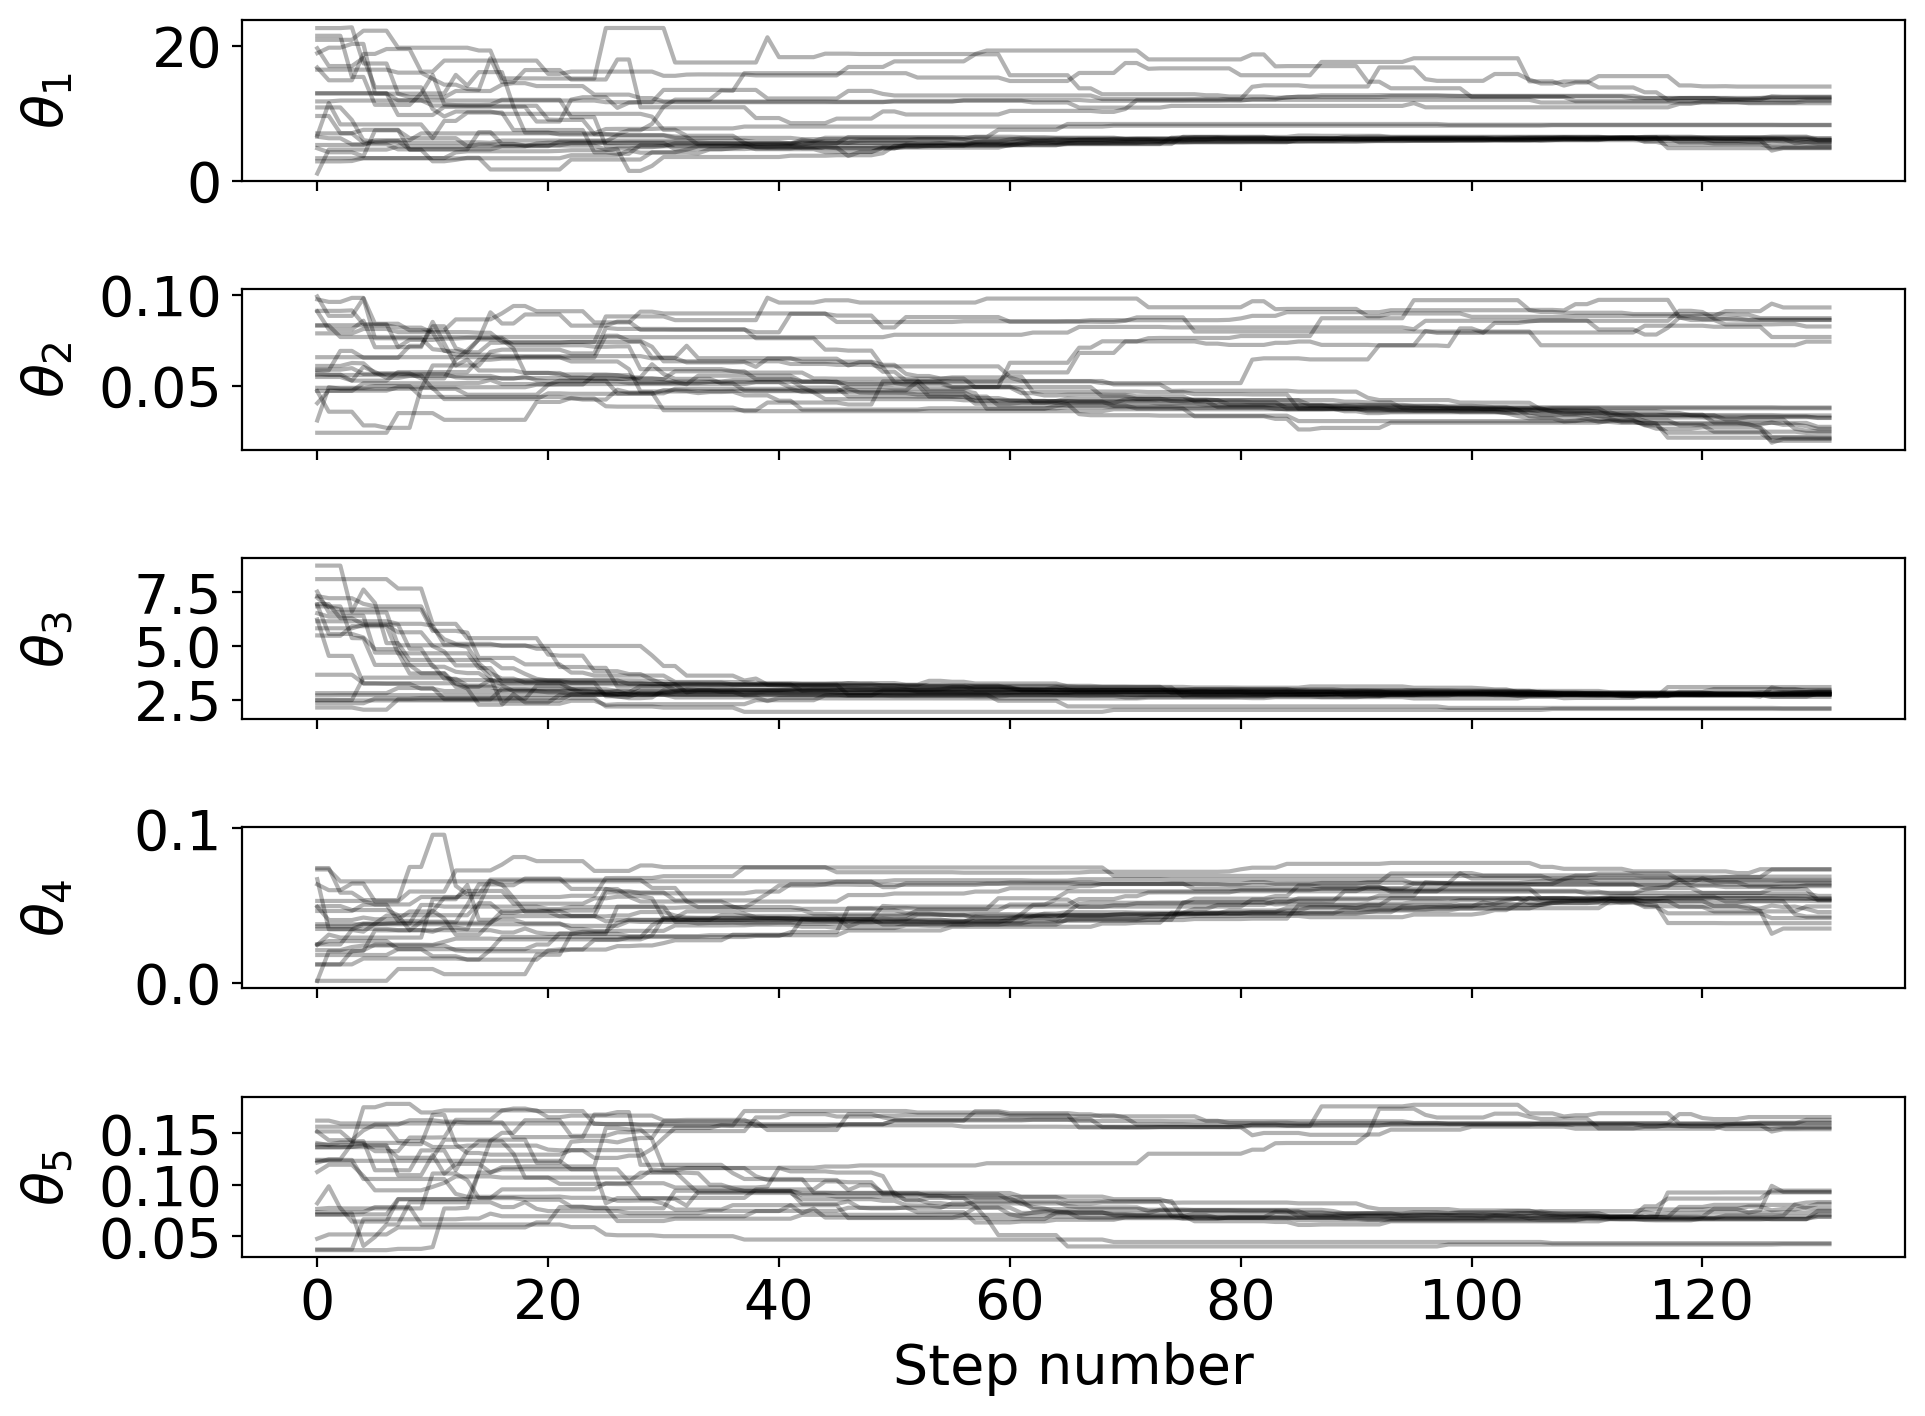

In [31]:
# Load the chain
chain = reader.get_chain()
ndim = chain.shape[2]

# Setup the plot
fig, axes = plt.subplots(ndim, figsize=(10, 1.5 * ndim), sharex=True)
labels = list(map(r"$\theta_{{{0}}}$".format, range(1, ndim + 1)))

for i in range(ndim):
    ax = axes[i]
    # Plot walkers with transparency to see density
    ax.plot(chain[:, :, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("Step number")
plt.tight_layout()
plt.show()

# Convergence Check (Autocorrelation)
This tells you mathematically how "independent" your samples are.

In [32]:
try:
    # We use tol=0 to force an estimate even if the chain is short
    tau = reader.get_autocorr_time(tol=0)
    mean_tau = np.mean(tau)
    
    print(f"Estimated Autocorrelation Time (tau): {mean_tau:.2f} steps")
    print(f"Burn-in suggestion (2 * tau): {int(2 * mean_tau)} steps")
    print(f"Thinning suggestion (0.5 * tau): {int(0.5 * mean_tau)} steps")
    
    # Heuristic: You usually want chain length > 50 * tau
    ratio = reader.iteration / mean_tau
    print(f"Convergence Ratio (Steps / tau): {ratio:.1f} (Aim for > 50)")

except Exception as e:
    print("Could not estimate autocorrelation time yet (chain likely too short/unstable).")

Estimated Autocorrelation Time (tau): 14.82 steps
Burn-in suggestion (2 * tau): 29 steps
Thinning suggestion (0.5 * tau): 7 steps
Convergence Ratio (Steps / tau): 8.9 (Aim for > 50)


# Posterior Corner Plot

Run this to see your results so far. Important: Update the discard value based on what you see in the Trace Plots (Cell 3).

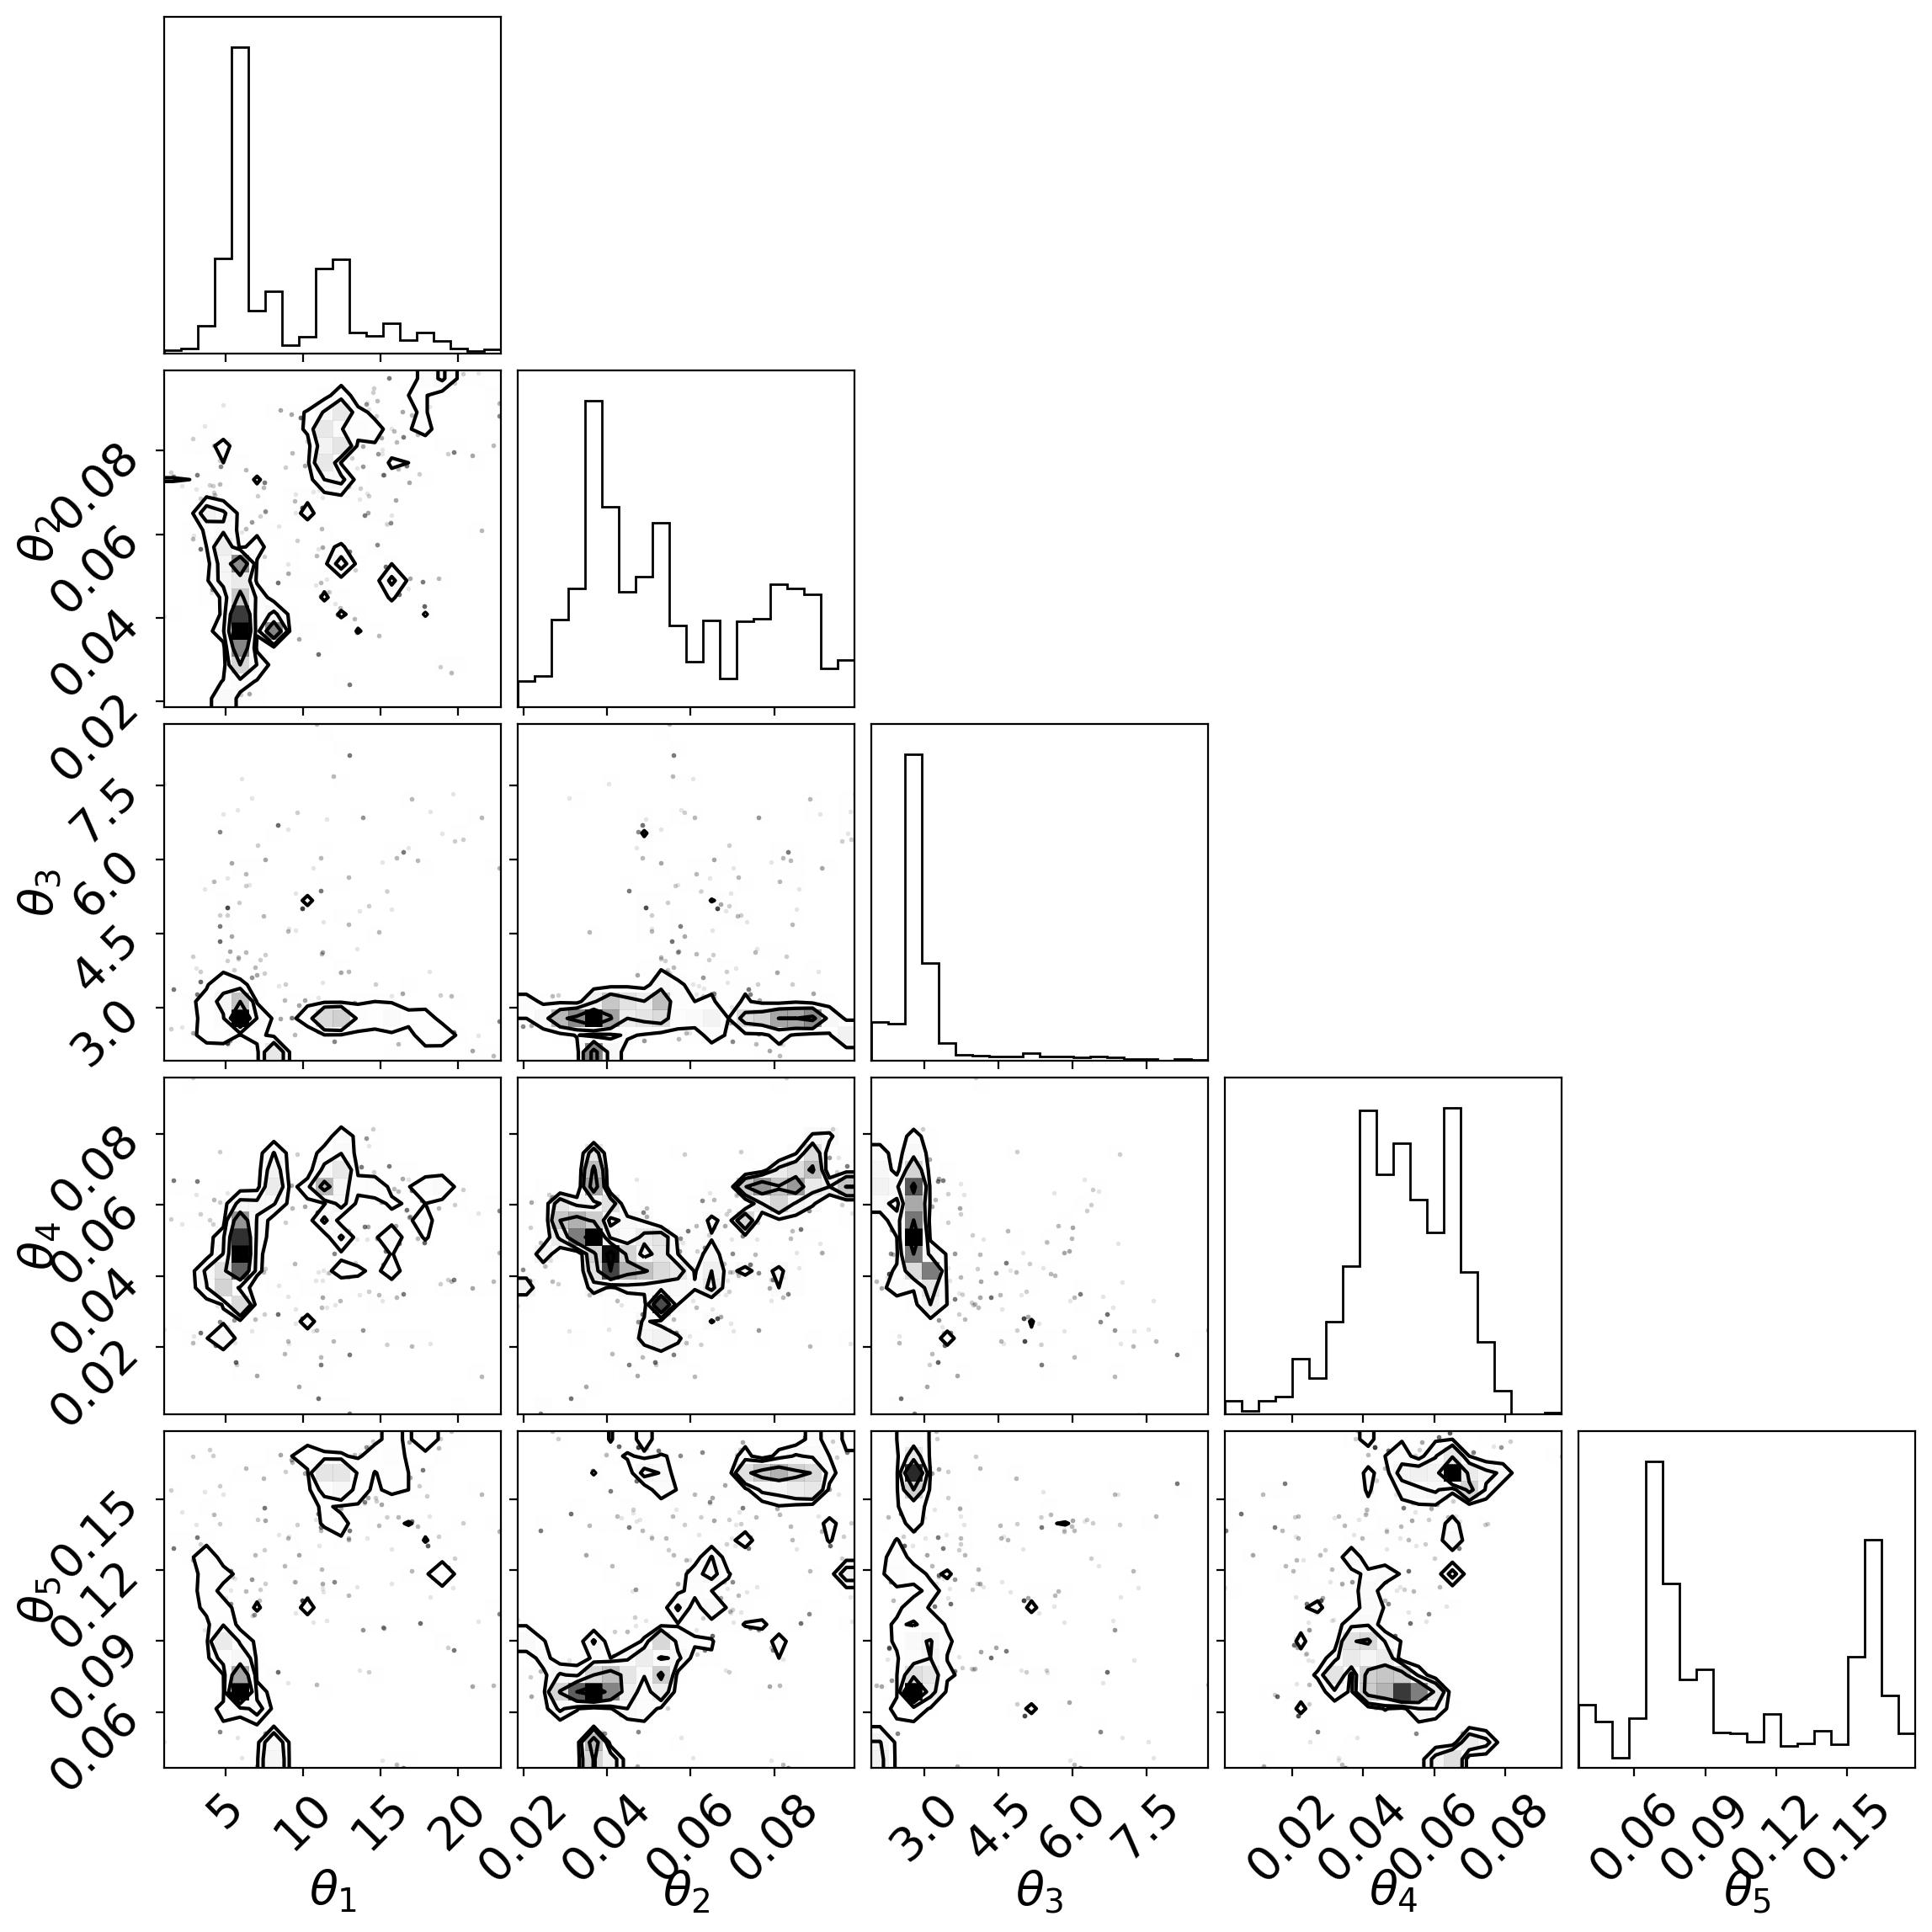

In [33]:
# Change this based on your visual inspection of Cell 3!
DISCARD_BURNIN = 0
THIN = 1

if reader.iteration > DISCARD_BURNIN:
    flat_samples = reader.get_chain(discard=DISCARD_BURNIN, thin=THIN, flat=True)
    
    fig = corner.corner(
        flat_samples, 
        labels=labels
    );
    plt.show()
else:
    print("Not enough steps to discard burn-in yet.")